
# Heart Disease Prediction

## Problem Statement
Build a binary classification model to predict whether a person is at risk of heart disease based on clinical health measurements.

This notebook follows a clean machine learning workflow:
- data loading and inspection,
- preprocessing and cleaning,
- exploratory data analysis,
- model training and validation,
- evaluation with accuracy, ROC-AUC, and confusion matrix,
- feature importance analysis,
- final insights.


## Import Libraries

In [25]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    fbeta_score,
    roc_curve,
    confusion_matrix,
    classification_report
)
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

RANDOM_STATE = 42
print("Libraries imported successfully.")


Libraries imported successfully.


## Load the Dataset

In [26]:

csv_files = glob.glob("/kaggle/input/datasets/fedesoriano/heart-failure-prediction/heart.csv", recursive=True)

if not csv_files:
    raise FileNotFoundError("No CSV file found under /kaggle/input. Please attach the Kaggle dataset.")

print("CSV files found:")
for f in csv_files:
    print(" -", f)

preferred = [f for f in csv_files if f.endswith("heart.csv")]
csv_path = preferred[0] if preferred else csv_files[0]

print(f"Using file: {csv_path}")

df = pd.read_csv(csv_path)
print("Dataset loaded successfully.")


CSV files found:
 - /kaggle/input/datasets/fedesoriano/heart-failure-prediction/heart.csv
Using file: /kaggle/input/datasets/fedesoriano/heart-failure-prediction/heart.csv
Dataset loaded successfully.


## Initial Inspection

In [27]:

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())


Shape: (918, 12)

Columns:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

First 5 rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [28]:

print("Data Information:")
df.info()


Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [29]:

print("Statistical Summary:")
display(df.describe(include="all"))


Statistical Summary:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,918.000000,918,918,918.000000,918.000000,918.000000,918,918.000000,918,918.000000,918,918.000000
unique,NaN,2,4,NaN,NaN,NaN,3,NaN,2,NaN,3,NaN
top,NaN,M,ASY,NaN,NaN,NaN,Normal,NaN,N,NaN,Flat,NaN
freq,NaN,725,496,NaN,NaN,NaN,552,NaN,547,NaN,460,NaN
mean,53.510893,NaN,NaN,132.396514,198.799564,0.233115,NaN,136.809368,NaN,0.887364,NaN,0.553377
std,9.432617,NaN,NaN,18.514154,109.384145,0.423046,NaN,25.460334,NaN,1.066570,NaN,0.497414
min,28.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN,60.000000,NaN,-2.600000,NaN,0.000000
25%,47.000000,NaN,NaN,120.000000,173.250000,0.000000,NaN,120.000000,NaN,0.000000,NaN,0.000000
50%,54.000000,NaN,NaN,130.000000,223.000000,0.000000,NaN,138.000000,NaN,0.600000,NaN,1.000000
75%,60.000000,NaN,NaN,140.000000,267.000000,0.000000,NaN,156.000000,NaN,1.500000,NaN,1.000000


## Data Cleaning

In [30]:

df.columns = [c.strip() for c in df.columns]

before_dupes = len(df)
df = df.drop_duplicates().copy()
after_dupes = len(df)

print(f"Removed {before_dupes - after_dupes} duplicate rows.")

for col in ["RestingBP", "Cholesterol"]:
    if col in df.columns:
        zero_count = (df[col] == 0).sum()
        if zero_count > 0:
            df[col] = df[col].replace(0, np.nan)
            print(f"Converted {zero_count} zero values to NaN in {col}")

print("\nMissing values after cleaning:")
display(df.isna().sum())


Removed 0 duplicate rows.
Converted 1 zero values to NaN in RestingBP
Converted 172 zero values to NaN in Cholesterol

Missing values after cleaning:


Age                 0
Sex                 0
ChestPainType       0
RestingBP           1
Cholesterol       172
FastingBS           0
RestingECG          0
MaxHR               0
ExerciseAngina      0
Oldpeak             0
ST_Slope            0
HeartDisease        0
dtype: int64

## Target Distribution

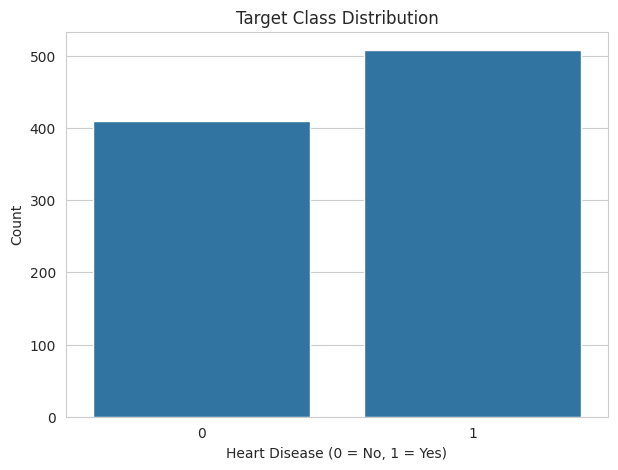

Class proportions:


HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64

In [31]:

target_col = "HeartDisease"

plt.figure(figsize=(7, 5))
sns.countplot(x=target_col, data=df)
plt.title("Target Class Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()

print("Class proportions:")
display(df[target_col].value_counts(normalize=True).rename("proportion"))


## Exploratory Data Analysis

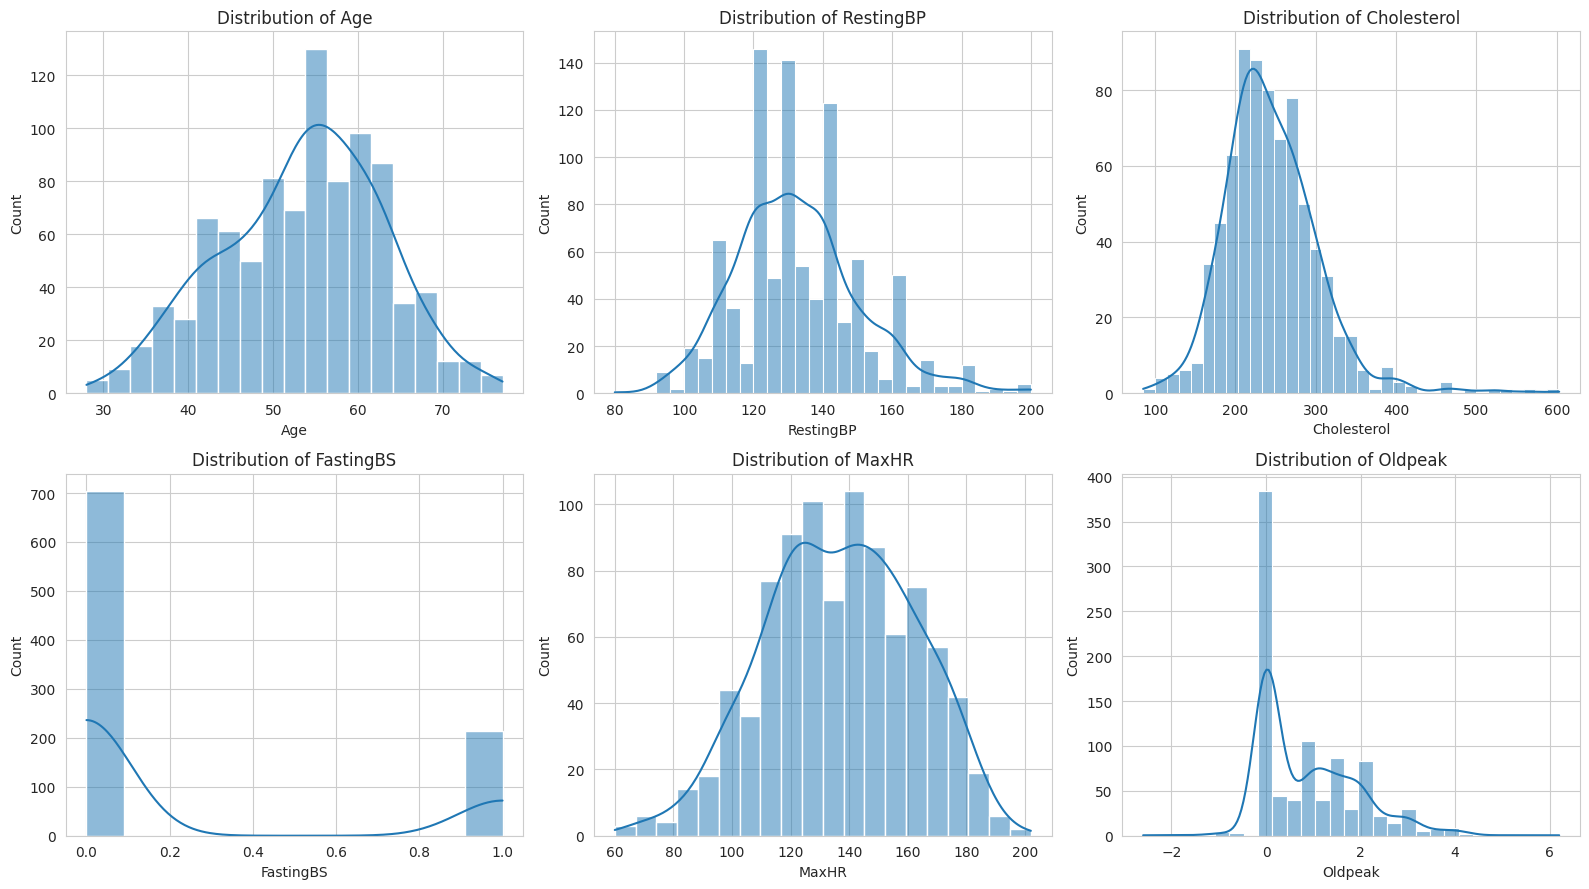

In [32]:

numeric_cols = [c for c in ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"] if c in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


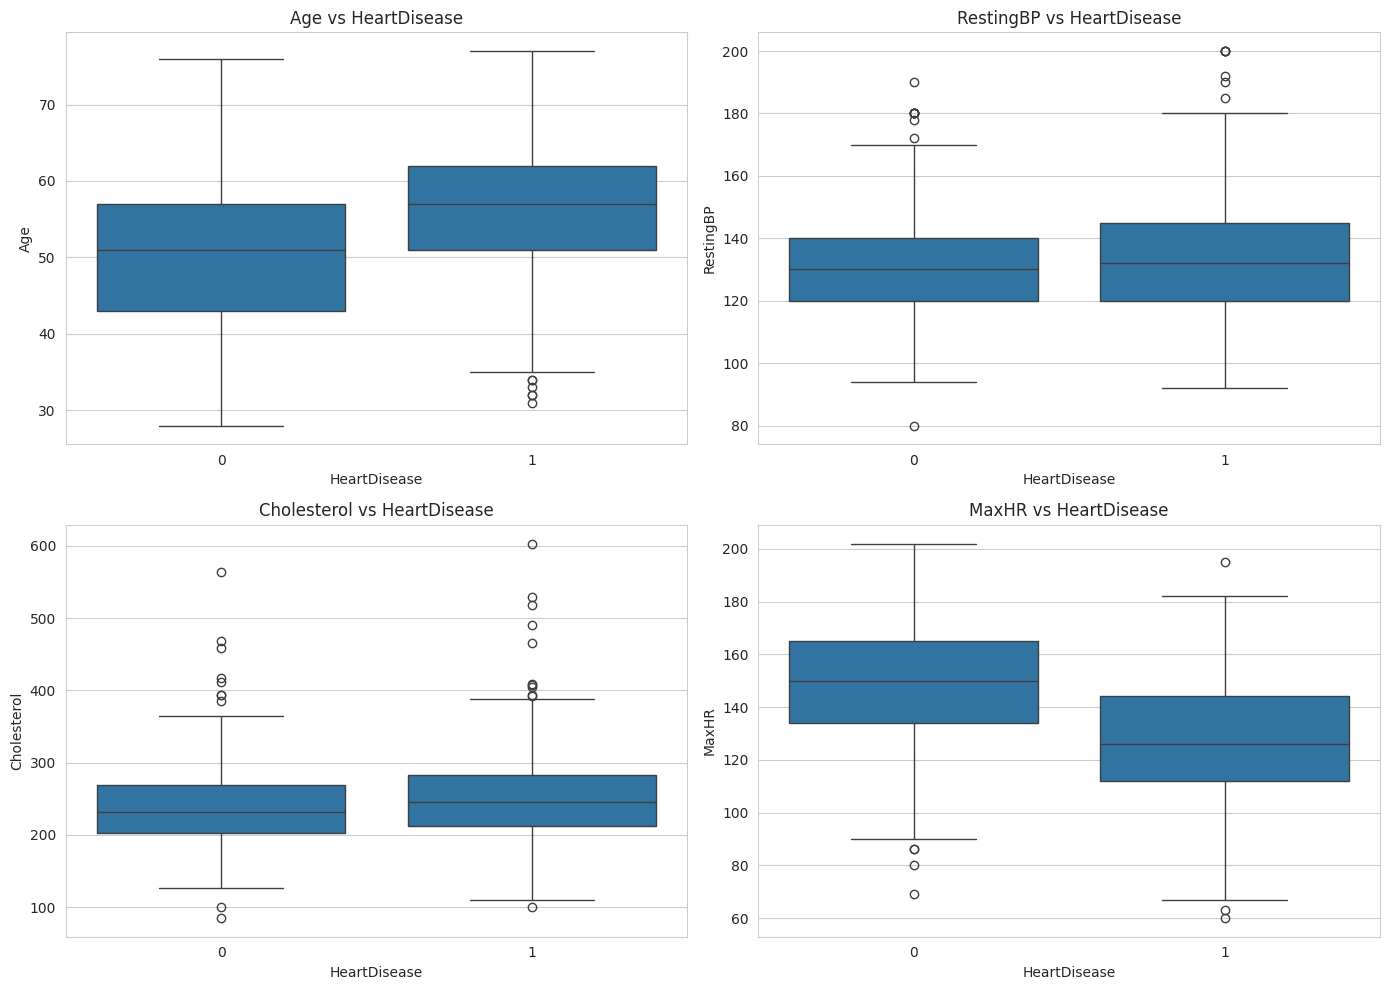

In [33]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

box_features = [c for c in ["Age", "RestingBP", "Cholesterol", "MaxHR"] if c in df.columns]

for ax, col in zip(axes, box_features):
    sns.boxplot(data=df, x=target_col, y=col, ax=ax)
    ax.set_title(f"{col} vs HeartDisease")

plt.tight_layout()
plt.show()


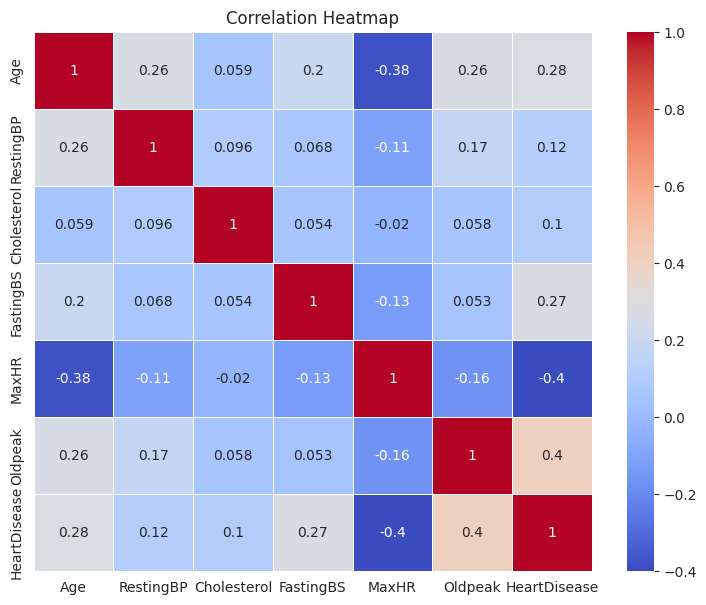

In [34]:

plt.figure(figsize=(9, 7))
corr = df[numeric_cols + [target_col]].corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()


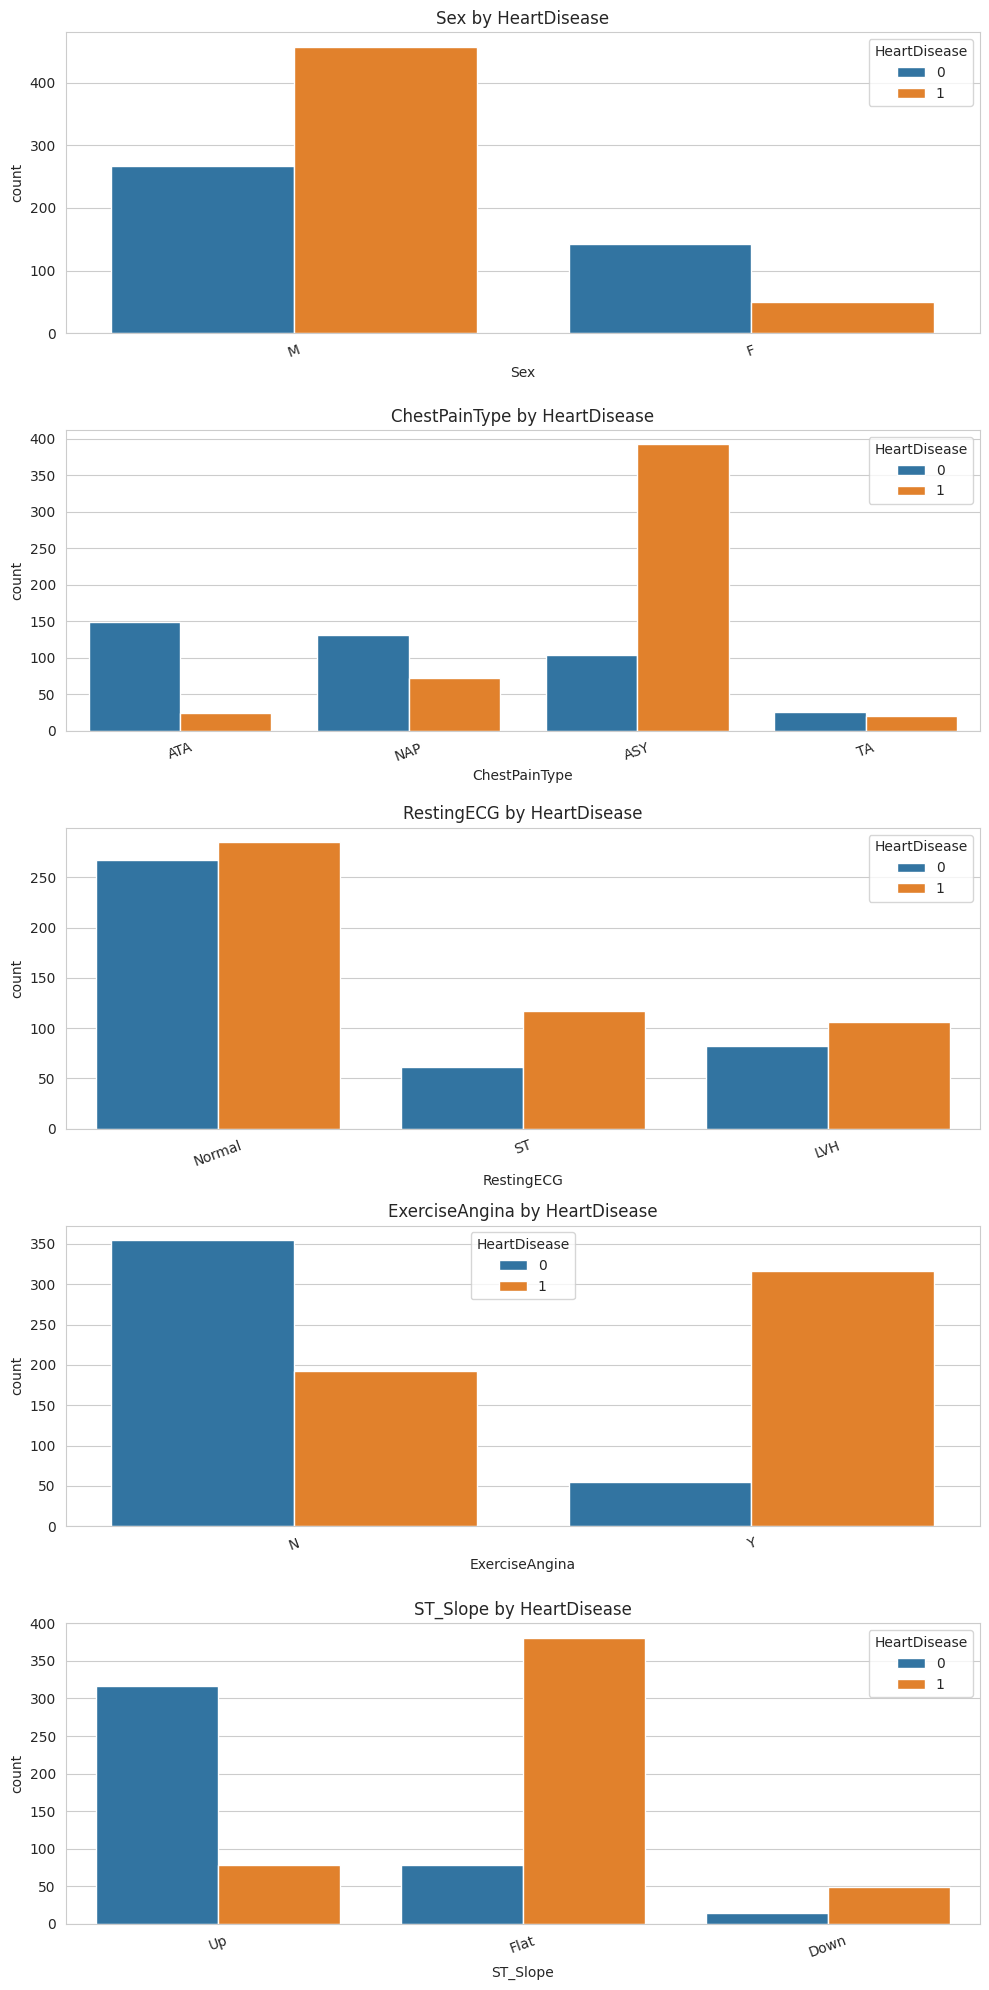

In [35]:

categorical_cols = [c for c in ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope"] if c in df.columns]

fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(10, 4 * len(categorical_cols)))

if len(categorical_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, categorical_cols):
    sns.countplot(data=df, x=col, hue=target_col, ax=ax)
    ax.set_title(f"{col} by HeartDisease")
    ax.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()


## Features and Target

In [36]:

X = df.drop(columns=[target_col])
y = df[target_col]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Feature matrix shape: (918, 11)
Target shape: (918,)


## Train / Validation / Test Split

In [37]:

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)
print("Test shape:", X_test.shape, y_test.shape)

print("\nTrain target proportion:")
display(y_train.value_counts(normalize=True).rename("proportion"))


Train shape: (642, 11) (642,)
Validation shape: (193, 11) (193,)
Test shape: (83, 11) (83,)

Train target proportion:


HeartDisease
1    0.55296
0    0.44704
Name: proportion, dtype: float64

## Preprocessing Pipeline

In [38]:

numeric_features = [c for c in X.columns if c in ["Age", "RestingBP", "Cholesterol", "FastingBS", "MaxHR", "Oldpeak"]]
categorical_features = [c for c in X.columns if c not in numeric_features]

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe)
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


Numeric features: ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
Categorical features: ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


## Model Training

In [39]:

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        solver="liblinear",
        class_weight="balanced",
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=10,
        random_state=RANDOM_STATE
    )
}

def evaluate_classifier(model, X_tr, y_tr, X_ev, y_ev, threshold=0.5):
    prob_tr = model.predict_proba(X_tr)[:, 1]
    prob_ev = model.predict_proba(X_ev)[:, 1]

    pred_tr = (prob_tr >= threshold).astype(int)
    pred_ev = (prob_ev >= threshold).astype(int)

    results = {
        "train_accuracy": accuracy_score(y_tr, pred_tr),
        "train_precision": precision_score(y_tr, pred_tr, zero_division=0),
        "train_recall": recall_score(y_tr, pred_tr, zero_division=0),
        "train_f1": f1_score(y_tr, pred_tr, zero_division=0),
        "train_roc_auc": roc_auc_score(y_tr, prob_tr),
        "eval_accuracy": accuracy_score(y_ev, pred_ev),
        "eval_precision": precision_score(y_ev, pred_ev, zero_division=0),
        "eval_recall": recall_score(y_ev, pred_ev, zero_division=0),
        "eval_f1": f1_score(y_ev, pred_ev, zero_division=0),
        "eval_roc_auc": roc_auc_score(y_ev, prob_ev),
        "train_prob": prob_tr,
        "eval_prob": prob_ev,
        "train_pred": pred_tr,
        "eval_pred": pred_ev,
    }
    return results

trained_models = {}
validation_rows = []

for name, clf in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", clf)
    ])
    pipe.fit(X_train, y_train)
    trained_models[name] = pipe

    scores = evaluate_classifier(pipe, X_train, y_train, X_val, y_val)
    validation_rows.append({
        "Model": name,
        "Train Accuracy": scores["train_accuracy"],
        "Val Accuracy": scores["eval_accuracy"],
        "Train Recall": scores["train_recall"],
        "Val Recall": scores["eval_recall"],
        "Train F1": scores["train_f1"],
        "Val F1": scores["eval_f1"],
        "Train ROC-AUC": scores["train_roc_auc"],
        "Val ROC-AUC": scores["eval_roc_auc"]
    })

validation_df = pd.DataFrame(validation_rows).sort_values("Val ROC-AUC", ascending=False)
display(validation_df)


,Model,Train Accuracy,Val Accuracy,Train Recall,Val Recall,Train F1,Val F1,Train ROC-AUC,Val ROC-AUC
0,Logistic Regression,0.841121,0.886010,0.842254,0.915888,0.854286,0.899083,0.926358,0.932515
1,Decision Tree,0.852025,0.875648,0.907042,0.906542,0.871448,0.889908,0.933744,0.908335


## Model Selection

In [40]:

best_model_name = validation_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print(f"Best model selected: {best_model_name}")


Best model selected: Logistic Regression


In [41]:
# Use the model trained on TRAIN only for threshold selection
threshold_model = trained_models[best_model_name] if "trained_models" in globals() else final_model

val_prob = threshold_model.predict_proba(X_val)[:, 1]

thresholds = np.linspace(0.10, 0.90, 81)
rows = []

for t in thresholds:
    val_pred_t = (val_prob >= t).astype(int)
    rows.append({
        "threshold": t,
        "accuracy": accuracy_score(y_val, val_pred_t),
        "precision": precision_score(y_val, val_pred_t, zero_division=0),
        "recall": recall_score(y_val, val_pred_t, zero_division=0),
        "f1": f1_score(y_val, val_pred_t, zero_division=0),
        "f2": fbeta_score(y_val, val_pred_t, beta=2, zero_division=0),
        "roc_auc": roc_auc_score(y_val, val_prob)  # threshold-independent
    })

threshold_results = pd.DataFrame(rows)

# Pick threshold that maximizes F2 (recall-focused), tie-break by higher recall
best_row = threshold_results.sort_values(
    ["f2", "recall", "precision"],
    ascending=[False, False, False]
).iloc[0]

best_threshold = float(best_row["threshold"])

print(f"Best threshold selected from validation: {best_threshold:.2f}")
display(threshold_results.sort_values("f2", ascending=False).head(10))

print("\nBest validation-threshold metrics:")
display(pd.DataFrame([best_row]))


Best threshold selected from validation: 0.37


,threshold,accuracy,precision,recall,f1,f2,roc_auc
27,0.37,0.896373,0.865546,0.962617,0.911504,0.941499,0.932515
28,0.38,0.896373,0.865546,0.962617,0.911504,0.941499,0.932515
22,0.32,0.886010,0.851240,0.962617,0.903509,0.938069,0.932515
24,0.34,0.886010,0.851240,0.962617,0.903509,0.938069,0.932515
25,0.35,0.886010,0.851240,0.962617,0.903509,0.938069,0.932515
26,0.36,0.886010,0.851240,0.962617,0.903509,0.938069,0.932515
23,0.33,0.886010,0.851240,0.962617,0.903509,0.938069,0.932515
18,0.28,0.880829,0.844262,0.962617,0.899563,0.936364,0.932515
20,0.30,0.880829,0.844262,0.962617,0.899563,0.936364,0.932515
21,0.31,0.880829,0.844262,0.962617,0.899563,0.936364,0.932515



Best validation-threshold metrics:


,threshold,accuracy,precision,recall,f1,f2,roc_auc
27,0.37,0.896373,0.865546,0.962617,0.911504,0.941499,0.932515


In [42]:
# Refit final model on TRAIN + VALIDATION
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

optimized_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", models[best_model_name])
])

optimized_model.fit(X_train_full, y_train_full)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'RestingBP',
                                                   'Cholesterol', 'FastingBS',
                                                   'MaxHR', 'Oldpeak']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Sex', 'ChestPainType',
                                                   'RestingECG',
                                                   'ExerciseAngina',
                                                   'ST_Slope'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=2000,
                                    random_state=42, solver='liblinear'))])

## Final Test Evaluation

In [43]:

X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

final_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", models[best_model_name])
])

final_model.fit(X_train_full, y_train_full)

test_prob = optimized_model.predict_proba(X_test)[:, 1]
test_pred = (test_prob >= best_threshold).astype(int)

test_metrics = {
    "Model": best_model_name,
    "Threshold": best_threshold,
    "Accuracy": accuracy_score(y_test, test_pred),
    "Precision": precision_score(y_test, test_pred, zero_division=0),
    "Recall": recall_score(y_test, test_pred, zero_division=0),
    "F1": f1_score(y_test, test_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, test_prob),
}

print("\nFinal test metrics with tuned threshold:")
display(pd.DataFrame([test_metrics]))

print("\nClassification report:")
print(classification_report(y_test, test_pred, digits=4))




Final test metrics with tuned threshold:


,Model,Threshold,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.37,0.86747,0.906977,0.847826,0.876404,0.933608



Classification report:
              precision    recall  f1-score   support

           0     0.8250    0.8919    0.8571        37
           1     0.9070    0.8478    0.8764        46

    accuracy                         0.8675        83
   macro avg     0.8660    0.8699    0.8668        83
weighted avg     0.8704    0.8675    0.8678        83



## Confusion Matrix

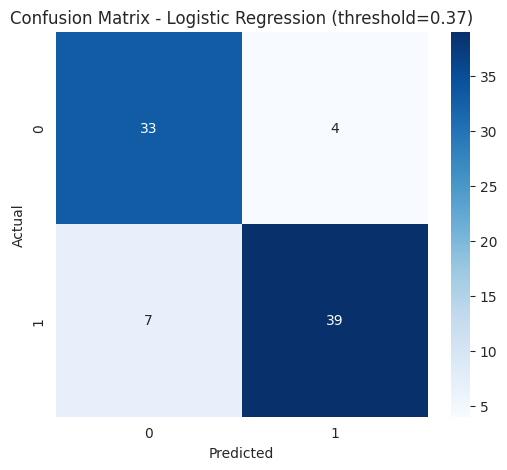

In [44]:
cm = confusion_matrix(y_test, test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name} (threshold={best_threshold:.2f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## ROC Curve

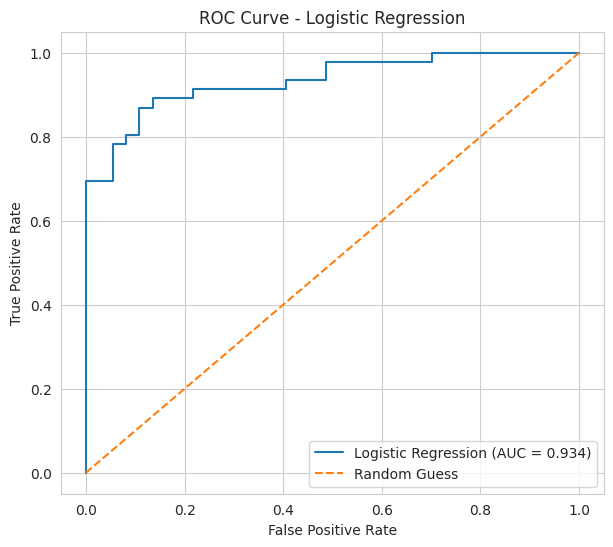

In [45]:
fpr, tpr, _ = roc_curve(y_test, test_prob)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {roc_auc_score(y_test, test_prob):.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")
plt.title(f"ROC Curve - {best_model_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Feature Importance Analysis

,Feature,Coefficient,AbsCoefficient
19,cat__ST_Slope_Up,-1.247327,1.247327
8,cat__ChestPainType_ASY,1.175536,1.175536
18,cat__ST_Slope_Flat,1.072707,1.072707
6,cat__Sex_F,-0.781718,0.781718
9,cat__ChestPainType_ATA,-0.624109,0.624109
3,num__FastingBS,0.604591,0.604591
15,cat__ExerciseAngina_N,-0.537928,0.537928
7,cat__Sex_M,0.523157,0.523157
11,cat__ChestPainType_TA,-0.441168,0.441168
5,num__Oldpeak,0.392277,0.392277


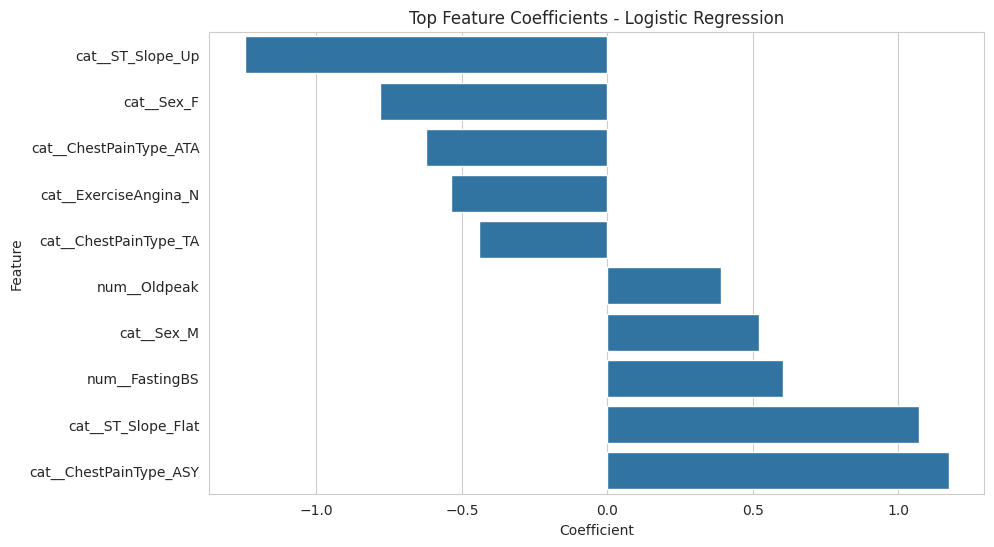

In [46]:

feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()
model_obj = final_model.named_steps["model"]

if hasattr(model_obj, "coef_"):
    importance = pd.DataFrame({
        "Feature": feature_names,
        "Coefficient": model_obj.coef_[0]
    })
    importance["AbsCoefficient"] = importance["Coefficient"].abs()
    importance = importance.sort_values("AbsCoefficient", ascending=False)

    display(importance.head(15))

    top_features = importance.head(10).sort_values("Coefficient")
    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_features, x="Coefficient", y="Feature")
    plt.title(f"Top Feature Coefficients - {best_model_name}")
    plt.show()

elif hasattr(model_obj, "feature_importances_"):
    importance = pd.DataFrame({
        "Feature": feature_names,
        "Importance": model_obj.feature_importances_
    }).sort_values("Importance", ascending=False)

    display(importance.head(15))

    top_features = importance.head(10).sort_values("Importance")
    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_features, x="Importance", y="Feature")
    plt.title(f"Top Feature Importances - {best_model_name}")
    plt.show()
else:
    print("This model does not expose coefficients or feature importances.")


## Save the Final Model

In [47]:
joblib.dump(optimized_model, "heart_disease_model.pkl")
print("Saved pipeline model as heart_disease_model.pkl")

model_bundle = {
    "model": optimized_model,
    "threshold": best_threshold,
    "best_model_name": best_model_name,
    "feature_columns": list(X.columns),
}

joblib.dump(model_bundle, "heart_disease_model_bundle.pkl")
print("\nSaved model bundle as heart_disease_model_bundle.pkl")


Saved pipeline model as heart_disease_model.pkl

Saved model bundle as heart_disease_model_bundle.pkl


In [48]:
# REAL UNSEEN DATA TEST

import numpy as np
import pandas as pd

# Use the final optimized model if available
model_for_inference = optimized_model if "optimized_model" in globals() else final_model

# Pick one real unseen patient from the test set
sample_idx = X_test.sample(1, random_state=42).index[0]

real_patient = X_test.loc[[sample_idx]].copy()
true_label = y_test.loc[sample_idx]

# Predict probability of heart disease
risk_prob = model_for_inference.predict_proba(real_patient)[:, 1][0]

# Apply the tuned threshold
pred_label = int(risk_prob >= best_threshold)

# Human-readable result
result_text = "HIGH RISK of heart disease" if pred_label == 1 else "LOW RISK of heart disease"

print("=== REAL UNSEEN PATIENT TEST ===")
display(real_patient)

print(f"True label            : {true_label}")
print(f"Predicted probability : {risk_prob:.4f}")
print(f"Decision threshold    : {best_threshold:.2f}")
print(f"Predicted class       : {pred_label}")
print(f"Prediction result     : {result_text}")

if pred_label == 1:
    print("Model suggests this patient should be flagged for medical follow-up.")
else:
    print("Model does not flag this patient as high risk at the current threshold.")

=== REAL UNSEEN PATIENT TEST ===


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope
552,71,M,NAP,144.0,221.0,0,Normal,108,Y,1.8,Flat


True label            : 1
Predicted probability : 0.8297
Decision threshold    : 0.37
Predicted class       : 1
Prediction result     : HIGH RISK of heart disease
Model suggests this patient should be flagged for medical follow-up.



## Final Insights
- The dataset is appropriate for binary classification and contains both numerical and categorical clinical variables.
- Stratified splitting preserves class balance and provides a realistic estimate of generalization.
- ROC-AUC is important for medical classification because ranking high-risk patients correctly matters beyond simple accuracy.
- Feature importance helps explain which clinical variables influence prediction most strongly.
